In [1]:
# 加载数据集
import torch
# 预测
import sys
sys.path.append("../")
from tools import getPairInfo, metric

# MACCSKeys
from predictor_iter import predict
modelPath = {
    'kcat':"../../IterTransferLearning/KCATModel/confirm-MACCS#openKKmInfer#openLog10-KCAT-train-8/model/pre-train-trainR2:0.9408-devR2=0.7459-RMSE=0.7751-MAE=0.4787-epoch=3",
    'km':"../../IterTransferLearning/KMModel/confirm-MACCS#openKKmInfer#openLog10-KM-train-8/model/pre-train-trainR2:0.9303-devR2=0.7163-RMSE=0.6960-MAE=0.4802-epoch=3",
    'kkm':"../../IterTransferLearning/KKMModel/confirm-MACCS#openKKmInfer#openLog10-KKM-train-8/model/pre-train-trainR2:0.9188-devR2=0.8245-RMSE=0.7592-MAE=0.5030-epoch=4"
}
# Unimol
# from predictor_uni import predict
# modelPath = {
#     'kcat':"../../IterTransferLearning/KCATModel/confirm-unimol-openKKMInfer&openLog10-KCAT-train-8/model/pre-train-trainR2:0.9123-devR2=0.7173-RMSE=0.8176-MAE=0.5188-epoch=18",
#     'km':"../../IterTransferLearning/KMModel/confirm-unimol-openKKMInfer&openLog10-KM-train-8/model/pre-train-trainR2:0.9561-devR2=0.7160-RMSE=0.6965-MAE=0.4844-epoch=4",
#     'kkm':"../../IterTransferLearning/KKMModel/confirm-unimol-openKKMInfer&openLog10-KKM-train-8/model/pre-train-trainR2:0.9270-devR2=0.8242-RMSE=0.7600-MAE=0.5041-epoch=3"
# }

# ECFP
# from predictor_iter import predict
# modelPath = {
#     'kcat':"../../IterTransferLearning/KCATModel/confirm-openKKMInfer#openLog10-KCAT-train-8/model/pre-train-trainR2:0.9564-devR2=0.7345-RMSE=0.7923-MAE=0.4740-epoch=3",
#     'km':"../../IterTransferLearning/KMModel/confirm-openKKMInfer#openLog10-KM-train-8/model/pre-train-trainR2:0.9440-devR2=0.7222-RMSE=0.6888-MAE=0.4736-epoch=2",
#     'kkm':"../../IterTransferLearning/KKMModel/confirm-openKKMInfer#openLog10-KKM-train-8/model/pre-train-trainR2:0.9513-devR2=0.8387-RMSE=0.7279-MAE=0.4810-epoch=19"
# }

# RDKIT
# from predictor_iter import predict
# modelPath = {
#     'kcat':"../../IterTransferLearning/KCATModel/confirm-RDKIT#openKKmInfer#openLog10-KCAT-train-8/model/pre-train-trainR2:0.9234-devR2=0.7388-RMSE=0.7859-MAE=0.5013-epoch=2",
#     'km':"../../IterTransferLearning/KMModel/confirm-RDKIT#openKKmInfer#openLog10-KM-train-8/model/pre-train-trainR2:0.9354-devR2=0.7026-RMSE=0.7127-MAE=0.4993-epoch=5",
#     'kkm':"../../IterTransferLearning/KKMModel/confirm-RDKIT#openKKmInfer#openLog10-KKM-train-8/model/pre-train-trainR2:0.9140-devR2=0.8155-RMSE=0.7785-MAE=0.5227-epoch=5"
# }

In [2]:
threshold = [(0, 0.4), (0.4, 0.8), (0.8, 0.99), (0.99, 1.0)]
result = {'kcat':{'MAE':[], 'rmse':[], 'r2':[], 'N':[]},
         'km':{'MAE':[], 'rmse':[], 'r2':[], 'N':[]},
          'kkm':{'MAE':[], 'rmse':[], 'r2':[], 'N':[]}
         }
for Type in ['kcat', 'km', 'kkm']:
    for index, item in enumerate(threshold):
        real, pre = predict(
                            Type.upper(),
                            modelPath[Type],
                            getPairInfo(*item, torch.load(f"../Data/{Type.upper()}TestDataSetSimi.pt"), torch.load(f"../Data/{Type.upper()}TestPairInfo")),
                            f"../../{Type.upper()}/Data/NewestFeature/esm1v_t33_650M_UR90S_1_embeding_1280/",
                            f"../../{Type.upper()}/Data/NewestFeature/index_smiles",
                            True,
                            torch.device("cuda:0"),
                            "MACCSKeys"
                           )
        res = metric(pre, real, True)
        result[Type]['MAE'].append(res['MAE'])
        result[Type]['rmse'].append(res['rmse'])
        result[Type]['r2'].append(res['r2'])
        result[Type]['N'].append(res['samples'])

log10:True molType:MACCSKeys
F


100%|███████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.04s/it]


log10:True molType:MACCSKeys
F


100%|███████████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.13s/it]


log10:True molType:MACCSKeys
F


...

100%|███████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.86s/it]


log10:True molType:MACCSKeys
complex
complex


100%|███████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.18s/it]


log10:True molType:MACCSKeys
complex
complex


100%|█████████████████████████████████████████████████████████████| 13/13 [00:05<00:00,  2.47it/s]


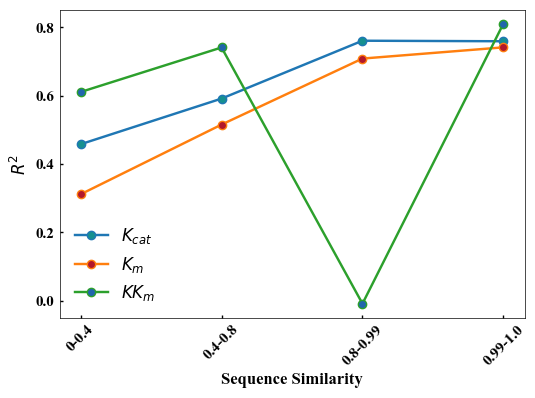

In [3]:
import matplotlib.pyplot as plt
from matplotlib import rc
plt.figure(figsize=(6,4))
rc('font',**{'family':'Times New Roman',})
plt.rcParams['pdf.fonttype'] = 42
# plt.axes([0.12,0.12,0.83,0.83])
plt.tick_params(direction='in')
plt.tick_params(which='major',length=2)
plt.tick_params(which='major',width=1)
plt.plot(list(range(4)),result['kcat']['r2'],linestyle='-',linewidth=1.75,marker='o',markerfacecolor='#159090', markersize=6, label='$K_{cat}$')
plt.plot(list(range(4)),result['km']['r2'],linestyle='-',linewidth=1.75,marker='o',markerfacecolor='#b2182b', markersize=6, label='$K_{m}$') 
plt.plot(list(range(4)),result['kkm']['r2'],linestyle='-',linewidth=1.75,marker='o',markerfacecolor='#2166ac', markersize=6, label='$KK_{m}$') 
plt.rcParams['font.family'] = 'Times New Roman'
plt.xticks(range(4), ["0-0.4", "0.4-0.8", "0.8-0.99", "0.99-1.0"],rotation=45, weight='bold', fontname='Times New Roman')
plt.xlabel('Sequence Similarity', fontsize=12, weight='bold', fontname='Times New Roman')
plt.ylabel('$R^{2}$', fontsize=12, weight='bold', fontname='Times New Roman')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, weight='bold', fontname='Times New Roman')
plt.legend(frameon=False, prop={"size":12})
ax = plt.gca()
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
# plt.savefig(f"../Fig/Fig9-iter8-RDKIT-smi.png", dpi=600,  bbox_inches='tight')

In [4]:
result

{'kcat': {'MAE': [1.0900842930729453,
   0.7016844307097099,
   0.6643688683501549,
   0.4551229367329943],
  'rmse': [1.4627983816889865,
   0.9976514324004543,
   1.0600825879008577,
   0.7425257819880963],
  'r2': [0.4578073078507291,
   0.5914789023404005,
   0.760978883138527,
   0.7594117128403066],
  'N': [38, 189, 45, 3172]},
 'km': {'MAE': [0.8364680087701841,
   0.6575027293669926,
   0.4096174572774193,
   0.46100839015079265],
  'rmse': [1.0960932510203283,
   0.951140342529896,
   0.628597109488304,
   0.6625807725589379],
  'r2': [0.31115979257239434,
   0.5153295759492279,
   0.7086990060154594,
   0.7415456883339687],
  'N': [44, 213, 57, 2551]},
 'kkm': {'MAE': [0.6769027397036552,
   0.5391010346787947,
   0.6452928520739079,
   0.5205774178144102],
  'rmse': [1.05589341990249,
   0.8538554050201551,
   0.9960503371368387,
   0.7840418875529085],
  'r2': [0.6107917512896308,
   0.7411834459083315,
   -0.009308501648914502,
   0.8108881510480694],
  'N': [20, 54, 12, 1

In [4]:
import json
with open("../Fig/Fig9-iter8-RDKIT-smi.json", 'w') as f:
    json.dump(result, f)

In [5]:
result

{'kcat': {'MAE': [1.0888745777406974,
   0.7008496357433537,
   0.6898000324765842,
   0.44978837009619643],
  'rmse': [1.4252937187395347,
   0.9855289313164842,
   1.1297551483526127,
   0.7623728714604902],
  'r2': [0.4852534319577403,
   0.6013464963929231,
   0.7285276970008145,
   0.7463783800155873],
  'N': [38, 189, 45, 3172]},
 'km': {'MAE': [0.9493481055410071,
   0.6462722509015054,
   0.45171817630660116,
   0.45163239016940926],
  'rmse': [1.201227657343341,
   0.9099945532222871,
   0.7241880652922612,
   0.653510052089823],
  'r2': [0.1726788492221275,
   0.5563557070411663,
   0.6133660967587246,
   0.7485737209572301],
  'N': [44, 213, 57, 2551]},
 'kkm': {'MAE': [0.6873234450817108,
   0.5038213029641796,
   0.5898857843130827,
   0.49372624238332113],
  'rmse': [0.9659395259242523,
   0.8033032977314143,
   0.6972369553209742,
   0.7435169813236625],
  'r2': [0.6742820113855683,
   0.7709224727478652,
   0.505436395094082,
   0.8299322392528542],
  'N': [20, 54, 12, 